In [1]:
#from dsigma.helpers import dsigma_table
from astropy.table import Table, vstack, dstack
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import astropy.units as u
from astropy.constants import G
from astropy.cosmology import Planck15
import matplotlib as mpl

In [2]:
lenspath='/sps/lsst/users/lbaumont/data/HSC/cluster_coverfraction.fits'
table_l=Table.read(lenspath)
#m_bins = np.array([12.2, 13.1, 13.4, 13.7, 14.0, 14.3, 15])

m_bins = np.array([12.2, 12.5,12.8, 13.1, 13.4, 13.7, 14.7])
bins = np.digitize(table_l['mass_lum'], m_bins)
pass

In [3]:
import matplotlib.colors as mcolors

# 1. Define a helper function to slice the colormap
def truncate_colormap(cmap_name, min_val=0.0, max_val=1.0, n=100):
    cmap = plt.get_cmap(cmap_name)
    # Extract colors from the specific range (0.0 to 1.0)
    colors = cmap(np.linspace(min_val, max_val, n))
    # Build and return the new truncated colormap
    return mcolors.LinearSegmentedColormap.from_list(f'trunc_{cmap_name}', colors)

Text(0, 0.5, 'log$_{10}$ (M /M$_\\odot$)')

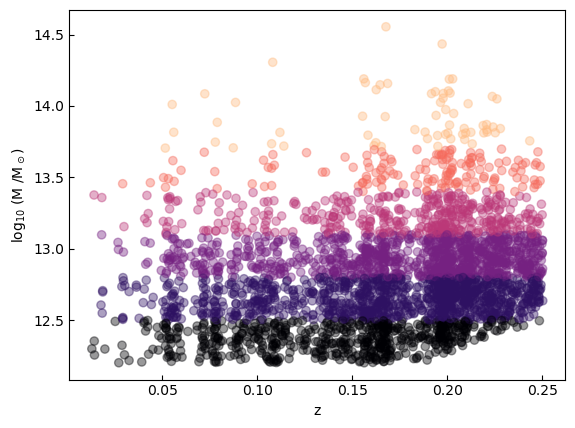

In [4]:
footprint=np.where((table_l['cf_1mpc']>.5) & (bins > 0)) 
sliced_cmap = truncate_colormap('magma', min_val=0.0, max_val=((len(m_bins)-1)/len(m_bins)))
plt.scatter(table_l['IterCenZ'][footprint], table_l['mass_lum'][footprint], c=bins[footprint], cmap=sliced_cmap,alpha=0.4)

plt.plot()
plt.tick_params(axis='both', direction='in')

plt.xlabel("z")
plt.ylabel(r"log$_{10}$ (M /M$_\odot$)")


In [ ]:
def radius_from_mass(logM, z, overdensity_factor):
    """radius from mass
    computes r_x in Mpc from log10(m_x) for a given critical overdensity factor x
    Parameters
    ----------
    logM: numpy.ndarray
        mass in solar masses
    z: numpy.ndarray
        redshift
    overdensity_factor: int
        overdensity factor 
    
    """
    mass=10**(logM)
    rhoc = Planck15.critical_density(.2).to(u.solMass / u.Mpc / u.Mpc / u.Mpc).value
    r = (3.0*mass / (4.0*np.pi*overdensity_factor*rhoc))**(0.33333)
    return r

In [ ]:
# get average mass in each mass bin
m_med = np.array([np.median(table_l['mass_lum'][bins==mass_bin+1]) for mass_bin in np.arange(len(m_bins)-1)])
print(m_med)
z_med=np.array([np.median(table_l['IterCenZ'][bins==mass_bin+1]) for mass_bin in np.arange(len(m_bins)-1)])
print(z_med)
r_med=radius_from_mass(m_med,z_med,200)
print(r_med)
m_mean = np.array([np.average(table_l['mass_lum'][bins==mass_bin+1]) for mass_bin in np.arange(len(m_bins)-1)])
print(m_mean)
z_mean=np.array([np.average(table_l['IterCenZ'][bins==mass_bin+1]) for mass_bin in np.arange(len(m_bins)-1)])
print(z_med)
r_mean=radius_from_mass(m_mean,z_mean,200)
print(r_mean)

# here is the list of arrays that we want
# and their shapes
(14, 15)["stacked_Dsigma"]
(14, 15)["stacked_theta"]
(14, 15)["stacked_variance"]
(400, 14, 15)["bs_theta"]
(400, 14, 15)["bs_Dsigma"]
['bs_Dsigma', 'bs_theta', 'stacked_Dsigma', 'stacked_theta', 'stacked_variance']

In [ ]:
# load boostrap table
table_list=[]
for i in np.arange(len(m_bins)-1):
    table_tmp=Table.read(f'/sps/lsst/users/lbaumont/software/dsigma_tmp/dsigma/tutorial/bs_hsc_{i}.parquet',format='parquet')
    table_tmp['mass_bin']=np.ones(len(table_tmp),dtype=int)*i
    table_list.append(table_tmp)
bs_table=dstack(table_list)
# convert from Mpc**2 to pc**2 units
bs_DS = bs_table["ds_t"].T*10**12
print(bs_DS.shape)
bs_theta=bs_table["rp"].T
print(bs_theta.shape)

In [ ]:
# load regular table

table_list=[]
for i in np.arange(len(m_bins)-1):
    table_tmp=Table.read(f'/sps/lsst/users/lbaumont/software/dsigma_tmp/dsigma/tutorial/boost_hsc_{i}.csv',format='csv')
    table_tmp['mass_bin']=np.ones(len(table_tmp),dtype=int)*i
    table_list.append(table_tmp)
full_table=dstack(table_list)
full_table['ds_t'].T.shape

In [ ]:
theta = full_table['rp'].T # Mpc
# change units of ds from M_sol*Mpc**2 to M_sol*pc**2
errs = full_table["ds_err"].T*10**12
DS = full_table["ds_t"].T*10**12


In [ ]:
plt.figure()
# Get a magma color for each scatter plot (0–1, one per dataset)
fig, ax = plt.subplots(layout='constrained')

cmap = plt.get_cmap('magma')
norm = mpl.colors.BoundaryNorm(m_bins, cmap.N)

#norm.vmax=14.7





colorizer = mpl.colorizer.Colorizer(norm=norm, cmap=sliced_cmap)
#colorizer.set_clim(4.7)
fig.colorbar(mpl.colorizer.ColorizingArtist(colorizer),
             ax=ax, orientation='vertical', label=r'log$_{10}$(M$_{lum}$/M$\odot$)')

colors = [cmap(i / 6) for i in range(7)]  # 6 colors: 0/5, 1/5, ..., 5/5

for i in range(theta.shape[0]):
    color = colors[i % 6]
    ax.errorbar(theta[i], DS[i], yerr=errs[i],  color=color,fmt="*")
    ax.set_xscale("log")
    ax.set_yscale("log")
plt.ylim(10**10,10**15)
plt.xlabel('R [Mpc]')
plt.ylabel(r'$\Delta \Sigma$ [M$_\odot$pc$^{-2}$]')
plt.tick_params(axis='both', which='both', direction='in')
#cmap = cm.get_cmap('magma')(hdulist[1].data[class_key]/num_cl)
pass
#plt.savefig("profiles.pdf", bbox_inches="tight")

In [ ]:
phi = np.linspace(0.00001, np.pi/2, num=200)
dphi = np.diff(phi)[0]
plt.plot(phi, 1/np.sin(phi), "*")

In [ ]:
# is this radius definition okay? What are the units?
r = np.logspace(-1, 0.5, num=10)

rsinphi = r[:, None]/np.sin(phi[None, :])

In [ ]:
rsinphi.max()

In [ ]:
integrand.shape

In [ ]:
plt.pcolor(np.log10(integrand[-6]))
plt.colorbar()

In [ ]:
# get delta_sigma values at r=r/sin(phi)
integrand = np.array([np.interp( np.log(rsinphi), np.log(theta[i]), DS[i] ) for i in range(DS.shape[0])])

inte = 4*np.sum(integrand, axis=-1)*dphi

g = inte*u.solMass/u.Mpc**2
g = g.to(u.kg/u.m**2) * G

M = r**2*inte

In [ ]:
nBS = bs_DS.shape[0]

g_bs = np.zeros(( nBS, DS.shape[0], len(r) ))
M_bs = np.zeros(( nBS, DS.shape[0], len(r) ))

for k in range(nBS):
    
    tt = bs_theta[k]
    dd = bs_DS[k]

    integrand = np.array([np.interp( np.log(rsinphi), 
                                    np.log(tt[i]), dd[i] ) for i in range(DS.shape[0])])

    inte = 4*np.sum(integrand, axis=-1)*dphi

    g = inte*u.solMass/u.Mpc**2
    g = g.to(u.kg/u.m**2) * G

    M = r**2*inte
    
    g_bs[k] = g
    M_bs[k] = M

In [ ]:
err_g_bs = np.nanstd(g_bs, axis=0)
mean_g_bs = np.nanmean(g_bs, axis=0)


In [ ]:
shift = 0.003
offset = -theta.shape[0]/2*shift
plt.figure()
for i in range(theta.shape[0]):
    color = colors[i % 6]
    plt.errorbar(r*np.power(10, offset+i*shift), mean_g_bs[i], yerr=err_g_bs[i],
                 color=color, marker="*")
    plt.xscale("log")
    plt.yscale("log")
plt.tick_params(axis='both', which='both', direction='in')
plt.xlabel("r [Mpc]")
plt.ylabel("g(r) [m s$^{-2}$]")

In [ ]:
err_m_bs = np.nanstd(M_bs, axis=0)
mean_m_bs = np.nanmean(M_bs, axis=0)

In [ ]:
mean_m_bs.shape

In [ ]:
r.shape

In [ ]:
table_list=[]
for i in range(theta.shape[0]):
    arr = {'r': r,
           'mean_m': mean_m_bs[i],
           'err_m': err_m_bs[i],
           'mass_bin': np.ones(len(r),dtype=int)*i,
          }
    x=Table(arr, names=('r', 'mean_m', 'err_m','mass_bin'))
    table_list.append(x)
y=vstack(table_list)


In [ ]:
#y.write("mass_table_v0.fits",overwrite=True)

In [ ]:
fig, ax = plt.subplots(layout='constrained')




norm = mpl.colors.BoundaryNorm(m_bins, cmap.N)

colorizer = mpl.colorizer.Colorizer(norm=norm, cmap=sliced_cmap)

fig.colorbar(mpl.colorizer.ColorizingArtist(colorizer),
             ax=ax, orientation='vertical', label=r'log$_{10}$(M$_{lum}$/M$\odot$)')

for i in range(theta.shape[0]):
    color = colors[i % len(m_bins)]
    ax.errorbar(r*np.power(10, offset+i*shift), mean_m_bs[i], yerr=err_m_bs[i],
                 color=color, marker="*")
    ax.set_xscale("log")
    ax.set_yscale("log")
    #ax.scatter(r_med[i], 10**m_med[i], color=color)
  
    #plt.plot(r_med[i]/1000, m_med[i]*1e13, "+", color=cmap[i], markersize=20)
plt.xlabel("r [Mpc]")
plt.ylabel(r"Enclosed Lensing Mass [M$\odot$]")
plt.ylim(10**10,10**15)
plt.tick_params(axis='both', which='both', direction='in')
plt.savefig("enclosed_mass.pdf", bbox_inches="tight")

In [ ]:
fig, ax = plt.subplots(layout='constrained')




norm = mpl.colors.BoundaryNorm(m_bins, cmap.N)

colorizer = mpl.colorizer.Colorizer(norm=norm, cmap=sliced_cmap)

fig.colorbar(mpl.colorizer.ColorizingArtist(colorizer),
             ax=ax, orientation='vertical', label=r'log$_{10}$(M$_{lum}$/M$\odot$)')

for i in range(theta.shape[0]):
    color = colors[i % len(m_bins)]
    ax.errorbar(r*np.power(10, offset+i*shift), mean_m_bs[i], yerr=err_m_bs[i],
                 color=color, marker="*")
    ax.set_xscale("log")
    ax.set_yscale("log")
    #ax.scatter(r_med[i], 10**m_med[i], color=color)
  
    #plt.plot(r_med[i]/1000, m_med[i]*1e13, "+", color=cmap[i], markersize=20)
plt.xlabel("r [Mpc]")
plt.ylabel(r"Enclosed Lensing Mass [M$\odot$]")
plt.ylim(10**10,10**15)
plt.tick_params(axis='both', which='both', direction='in')
plt.savefig("enclosed_mass.pdf", bbox_inches="tight")

In [ ]:
plt.figure()
for i in range(theta.shape[0]):
    color = colors[i % len(m_bins)]
    plt.errorbar(r*np.power(10, offset+i*shift), mean_m_bs[i], yerr=err_m_bs[i],
                 color=color, marker="*")
    plt.xscale("log")
    plt.yscale("log")
    #plt.plot(r_med[i]/1000, m_med[i]*1e13, "+", color=cmap[i], markersize=20)
plt.xlabel("r [Mpc]")
plt.ylabel("M [Msol]")
plt.ylim(10**10,10**15)

In [ ]:
for i in np.arange(8):
    mass_bin=full_table['mass_bin']==i
    color = colors[i % len(m_bins)]
    plt.errorbar(full_table['rp'][mass_bin],full_table['ds_t'][mass_bin],full_table['ds_err'][mass_bin], color=color, label=f'mass_bin {i+1}')
    #plt.errorbar(full_table['rp'][mass_bin],full_table['ds_raw'][mass_bin]-full_table['ds'][mass_bin],full_table['ds_err'][mass_bin],label=f'mass_bin {i+1}')
    #plt.legend()
    plt.xlabel('r [mpc]')
    plt.ylabel(r'$\Delta\Sigma_t$')
    plt.xscale('log')


In [ ]:
for i in np.arange(len(m_bins) -1):
    mass_bin_edge1=m_bins[i]
    mass_bin_edge2=m_bins[i+1]
    mass_bin=full_table['mass_bin']==2
    color = colors[i % len(m_bins)]
    plt.errorbar(full_table['rp'][mass_bin],full_table['ds_x'][mass_bin],full_table['ds_x_err'][mass_bin], color=color, label=f'mass [{mass_bin_edge1},{mass_bin_edge2}]')
    #plt.errorbar(full_table['rp'][mass_bin],full_table['ds_raw'][mass_bin]-full_table['ds'][mass_bin],full_table['ds_err'][mass_bin],label=f'mass_bin {i+1}')
    plt.legend()
    plt.xlabel('r [mpc]')
    plt.ylabel(r'$\Delta\Sigma_x$')
    plt.xscale('log')

In [ ]:
for i in np.arange(8):
    mass_bin=full_table['mass_bin']==i
    plt.errorbar(full_table['rp'][mass_bin],full_table['ds'][mass_bin],full_table['ds_err'][mass_bin],label=f'mass_bin {i+1}')
    plt.legend()
    plt.xlabel('r[mpc]')
    plt.ylabel(r'$\Delta\Sigma$')

In [ ]:
test=['x']
for i in test:
    print(i)